# Cvičení 2: LOESS a Mnohonásobná regrese
**Cíl:** Porovnat predikční schopnosti LOESS a polynomiální regrese. Následně provést průzkum a mnohonásobnou lineární regresi na datové sadě cen nemovitostí.

## Úkol 1: Porovnání LOESS a polynomiální regrese

In [35]:
import warnings
warnings.filterwarnings('ignore') # Pro čistší výstup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from scipy.interpolate import interp1d

# Načtení dat a příprava proměnných
df1 = pd.read_csv('Synthetic_dataset_1.csv')
X = df1['X'].values
y = df1['Y'].values

# 1. Rozdělení na trénovací a testovací množinu (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Pro LOESS je nutné mít trénovací data seřazená podle osy X
sort_idx = np.argsort(X_train)
X_train_sorted = X_train[sort_idx]
y_train_sorted = y_train[sort_idx]

In [36]:
# 2. Natrénování LOESS modelu na trénovacích datech
# Parametr frac=0.3 určuje podíl dat pro lokální vyhlazení
loess_fit = sm.nonparametric.lowess(y_train_sorted, X_train_sorted, frac=0.3)

# Vytvoření interpolační funkce pro predikci na testovacích datech
loess_interp = interp1d(loess_fit[:, 0], loess_fit[:, 1], bounds_error=False, fill_value="extrapolate")
y_pred_loess = loess_interp(X_test)

# 3. Natrénování polynomiální regrese a výběr optimálního stupně přes RMSE
best_d = 1
best_rmse = float('inf')
best_poly_model = None
best_poly_features = None

for d in range(1, 8):
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))

    model = LinearRegression().fit(X_train_poly, y_train)
    y_train_pred = model.predict(X_train_poly)

    rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    if rmse < best_rmse:
        best_rmse = rmse
        best_d = d
        best_poly_model = model
        best_poly_features = poly

print(f"Nejlepší stupeň polynomu (dle nejnižšího RMSE na trénovací sadě): d = {best_d}")

# Aplikace zvoleného polynomu na testovací sadu
X_test_poly = best_poly_features.transform(X_test.reshape(-1, 1))
y_pred_poly = best_poly_model.predict(X_test_poly)

Nejlepší stupeň polynomu (dle nejnižšího RMSE na trénovací sadě): d = 7


,RMSE,R2
Model,,
LOESS,0.923605,0.757216
Polynom (d=7),0.872686,0.783248


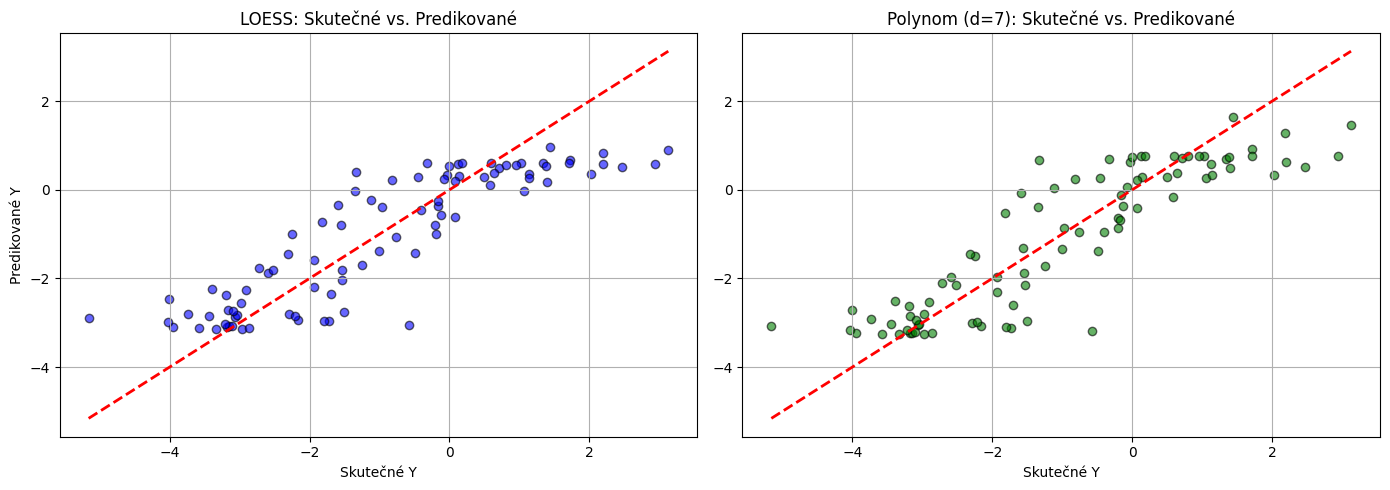

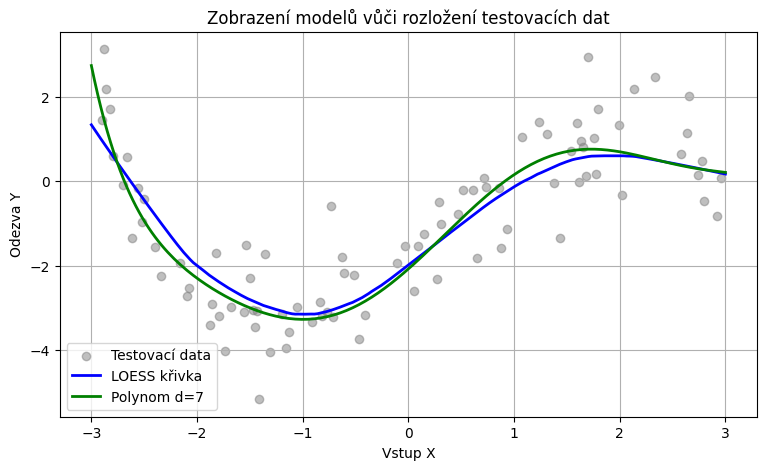

In [37]:
# 4. Vyhodnocení na testovací množině
results = {
    'Model': ['LOESS', f'Polynom (d={best_d})'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_loess)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly))
    ],
    'R2': [
        r2_score(y_test, y_pred_loess),
        r2_score(y_test, y_pred_poly)
    ]
}
display(pd.DataFrame(results).set_index('Model'))

# 5. Vizuální porovnání (Skutečné vs. Predikované hodnoty)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# LOESS - predikce
axs[0].scatter(y_test, y_pred_loess, alpha=0.6, color='blue', edgecolor='k')
axs[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axs[0].set_title('LOESS: Skutečné vs. Predikované')
axs[0].set_xlabel('Skutečné Y')
axs[0].set_ylabel('Predikované Y')
axs[0].grid(True)

# Polynom - predikce
axs[1].scatter(y_test, y_pred_poly, alpha=0.6, color='green', edgecolor='k')
axs[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axs[1].set_title(f'Polynom (d={best_d}): Skutečné vs. Predikované')
axs[1].set_xlabel('Skutečné Y')
axs[1].grid(True)

plt.tight_layout()
plt.savefig('loess_poly_porovnani.png', dpi=300)
plt.show()

# Proložení křivek modelů přes původní data (vizualizace flexibility)
X_plot = np.linspace(X.min(), X.max(), 200)
plt.figure(figsize=(9, 5))
plt.scatter(X_test, y_test, color='gray', label='Testovací data', alpha=0.5)
plt.plot(X_plot, loess_interp(X_plot), color='blue', label='LOESS křivka', lw=2)
plt.plot(X_plot, best_poly_model.predict(best_poly_features.transform(X_plot.reshape(-1, 1))), color='green', label=f'Polynom d={best_d}', lw=2)
plt.title('Zobrazení modelů vůči rozložení testovacích dat')
plt.xlabel('Vstup X')
plt.ylabel('Odezva Y')
plt.legend()
plt.grid(True)
plt.savefig('modely_na_datech.png', dpi=300)
plt.show()

### 6. Diskuze: LOESS vs. Polynomiální regrese
* **LOESS (Neparametrický model):** Přizpůsobuje se datům lokálně a nevyžaduje globální matematický předpis. Jeho hlavní výhodou je schopnost modelovat libovolně složité a nečekané nelineární závislosti (viz průběh na grafu). Na druhou stranu nevypočítá konkrétní rovnici s parametry, nehodí se pro extrapolaci mimo rozsah trénovacích dat a výpočetní náročnost roste s množstvím dat.
* **Polynomiální regrese (Parametrický model):** Předpokládá pevně stanovenou globální strukturu (určenou stupněm polynomu). Získáme konkrétní parametry ($\beta_0 \dots \beta_d$), což usnadňuje interpretaci a dosazování nových hodnot (extrapolaci). Je však méně variabilní než LOESS a pokud zvolíme příliš vysoký stupeň polynomu, rychle dochází k přeučení na trénovacích datech (křivka mezi body může začít divoce oscilovat).

## Úkol 2: Mnohonásobná lineární regrese
**Cíl:** Analyzovat datovou sadu (House price), posoudit vliv jednotlivých prediktorů a ověřit model mnohonásobné regrese.

--- Základní informace o datech ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB

--- Počet chybějících hodnot ---


CRIM       0
ZN         0
INDUS      0
CHAS       0
NX         0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

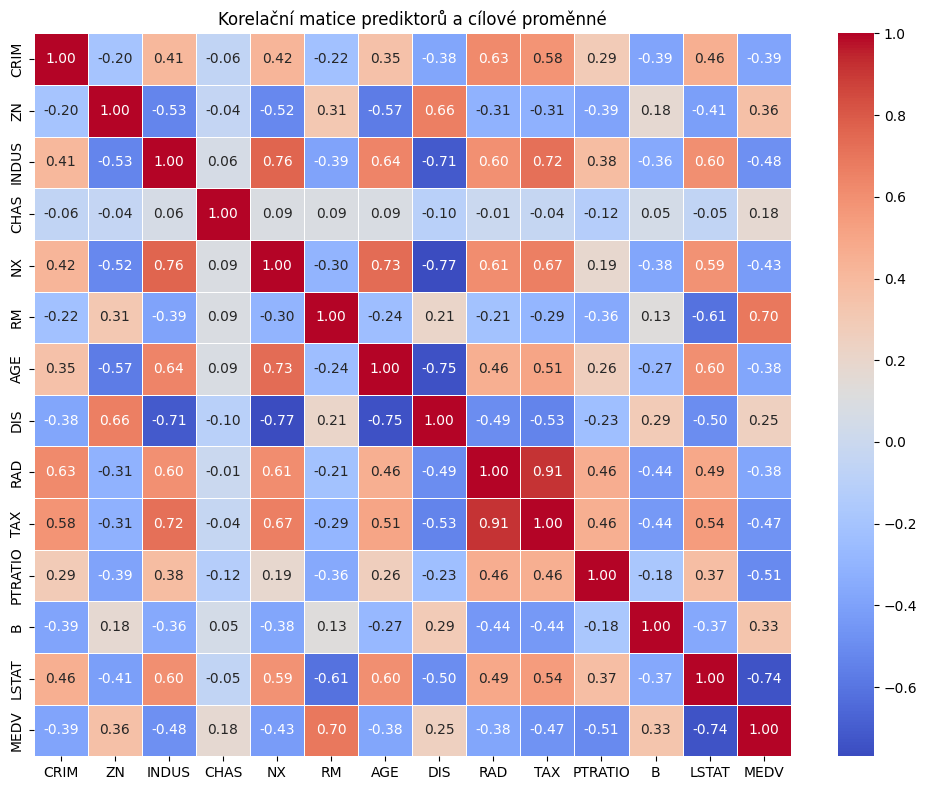

In [38]:
# 1. Průzkum dat (EDA) a identifikace cílové proměnné
df_house = pd.read_csv('house_data.csv')

print("--- Základní informace o datech ---")
df_house.info()
print("\n--- Počet chybějících hodnot ---")
display(df_house.isnull().sum())

# Odstranění chybějících hodnot pro zjednodušení modelu
df_house = df_house.dropna()

# Cílová proměnná pro predikci ceny nemovitosti
target_col = 'MEDV' if 'MEDV' in df_house.columns else df_house.columns[-1]

# 2. Diagnostika prediktorů - Zobrazení korelační matice
plt.figure(figsize=(10, 8))
corr_matrix = df_house.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelační matice prediktorů a cílové proměnné')
plt.tight_layout()
plt.savefig('korelacni_matice.png', dpi=300)
plt.show()

**Diagnostika multikolinearity:**
Z heatmapy sledujeme korelační koeficienty mezi jednotlivými prediktory. Pokud jsou některé proměnné navzájem silně korelované (ideálně se hledají hodnoty nad 0.7 resp. pod -0.7), značí to přítomnost multikolinearity. Ta může regresnímu modelu (OLS) způsobovat problémy při odhadech parametrů (nízká stabilita koeficientů, neprůkazné t-testy a obtížná interpretace vlivu jednotlivých znaků). Pokud by se u určité dvojice prediktorů potvrdila téměř dokonalá závislost, bylo by na místě jeden z nich z dalšího modelování vyloučit.

In [39]:
# Ostatní sloupce použijeme jako prediktory
X_multi = df_house.drop(columns=[target_col])
y_multi = df_house[target_col]

# 3. Rozdělení dat na trénovací (70 %) a testovací (30 %) sadu
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42)

# Výpočet potřebuje explicitně přidat vektor jedniček pro odhadnutí absolutního členu (β0)
X_train_m_const = sm.add_constant(X_train_m)
X_test_m_const = sm.add_constant(X_test_m)

# 4. Natrénování OLS (Ordinary Least Squares) modelu pro odhad parametrů (Y = β0 + β1X1 + ... + βpXp + ε)
ols_model = sm.OLS(y_train_m, X_train_m_const).fit()

# 5. Zobrazení statistické interpretace modelu
# Obsahuje celkový F-test, t-testy pro jednotlivé koeficienty i Adjusted R-squared
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     75.81
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           4.96e-92
Time:                        10:44:29   Log-Likelihood:                -1053.8
No. Observations:                 354   AIC:                             2136.
Df Residuals:                     340   BIC:                             2190.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.6311      6.056      5.223      0.0

In [40]:
# 6. Predikční hodnocení aplikované na testovací sadu
y_pred_multi = ols_model.predict(X_test_m_const)

rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))
r2_multi = r2_score(y_test_m, y_pred_multi)

print("=== Vyhodnocení vícerozměrného modelu ===")
print(f"RMSE (Root Mean Squared Error): {rmse_multi:.4f}")
print(f"R-squared (R2): {r2_multi:.4f}")

=== Vyhodnocení vícerozměrného modelu ===
RMSE (Root Mean Squared Error): 4.6387
R-squared (R2): 0.7112
